<a href="https://colab.research.google.com/github/b3bel23/Projetos-Python/blob/main/Trabalho2_MDipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

#### Lendo base de dados e removendo valores aleatoriamente **executar SEM ALTERAR**

In [ ]:
#Carregando base de dados
penguins = sns.load_dataset('penguins')

np.random.seed(42)  #Definindo seed do random para replicabilidade

#Removendo valores
removidos = set()
porcentagem = 0.30 #Porcentagem (0~1) das células a serem removidas
qtdCelulas = len(penguins)*(len(penguins.columns)) #Quantidade de células na base de dados, ignorando a última coluna

for i in range(int(np.ceil(porcentagem*qtdCelulas))):
  linha = np.random.randint(0, len(penguins))
  coluna = np.random.randint(0, len(penguins.columns))
  while (linha, coluna) in removidos:
    linha = np.random.randint(0, len(penguins))
    coluna = np.random.randint(0, len(penguins.columns))

  penguins.iloc[linha, coluna] = np.nan
  removidos.add((linha,coluna))

penguins.info()
print("\n\nForam removidas",str(len(removidos)), "células das",str(qtdCelulas))
del removidos
del qtdCelulas
del porcentagem

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            232 non-null    object 
 1   island             241 non-null    object 
 2   bill_length_mm     233 non-null    float64
 3   bill_depth_mm      244 non-null    float64
 4   flipper_length_mm  247 non-null    float64
 5   body_mass_g        240 non-null    float64
 6   sex                235 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Foram removidas 723 células das 2408


< copy p/ salvar >

In [ ]:
penguinsOriginalNa = penguins.copy()
penguinsOriginalNa

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,NaN,18.7,NaN,3750.0,Male
1,NaN,NaN,39.5,17.4,186.0,NaN,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie,NaN,NaN,19.3,193.0,3450.0,NaN
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,NaN,46.8,14.3,215.0,NaN,NaN
341,NaN,Biscoe,NaN,NaN,NaN,5750.0,NaN
342,Gentoo,Biscoe,45.2,14.8,NaN,5200.0,Female


### Filtros para manipular a Imputação de Categorias Categóricas e Categorias Numéricas

In [ ]:
list(penguins.columns)

['species',
 'island',
 'bill_length_mm',
 'bill_depth_mm',
 'flipper_length_mm',
 'body_mass_g',
 'sex']

In [ ]:
colunas_numericas = list(penguins.columns)
colunas_numericas.remove('species')
colunas_numericas.remove('sex')
colunas_numericas.remove('island')
colunas_numericas

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [ ]:
colunas_categoricas = list(penguins.columns)
colunas_categoricas.remove('bill_length_mm')
colunas_categoricas.remove('bill_depth_mm')
colunas_categoricas.remove('flipper_length_mm')
colunas_categoricas.remove('body_mass_g')
colunas_categoricas

['species', 'island', 'sex']

###Imputação de Colunas Categóricas - Moda

####Justificativa - Método Moda

Para preencher os valores ausentes nas colunas categóricas (`species`, `island` e `sex`), utilizamos uma estratégia baseada na moda, que é o valor mais frequente em uma coluna. Escolhemos essa abordagem porque a moda é simples de aplicar e faz sentido em dados categóricos, já que representa a categoria mais comum observada.

**Estratégia aplicada:**

- **`species`**: foi imputada com a **moda global** da coluna, ou seja, o valor mais comum considerando todos os dados. Fizemos isso porque `species` é uma variável central no conjunto de dados, e imputá-la com base em outras colunas poderia causar circularidade (usar uma variável que ainda depende de imputação para preencher outra).

- **`island` e `sex`**: foram imputadas com base na **moda por grupo de espécie**, ou seja, dentro de cada grupo de uma mesma espécie. Isso foi feito porque diferentes espécies costumam viver em ilhas específicas e podem ter distribuição diferente entre machos e fêmeas.

Esse método foi escolhido para evitar distorções. Se usássemos apenas a moda geral, poderíamos acabar colocando muitas entradas com o valor mais comum, mesmo em casos onde o valor mais comum **não faz sentido dentro daquele grupo**. Por exemplo, atribuir uma ilha errada a uma espécie que não vive lá.

####Código de Imputação

In [ ]:
#Copia o DataFrame com apenas as colunas categóricas
penguins_categoricasDF = penguinsOriginalNa[colunas_categoricas].copy()

In [ ]:
#Imputação da coluna 'species' com a moda geral
moda_species = penguins_categoricasDF['species'].mode()[0]
penguins_categoricasDF['species'].fillna(moda_species, inplace=True)

<ipython-input-53-a1caab6b78bd>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  penguins_categoricasDF['species'].fillna(moda_species, inplace=True)


In [ ]:
#Pega os rótulos únicos da espécie (sem NaN, já foram imputados)
rotulos_species = penguins_categoricasDF['species'].unique()

#Imputar as demais colunas categóricas com moda por espécie
for col in colunas_categoricas:
    if col == 'species':
        continue  # já foi imputada
    for especie in rotulos_species:
        filtro = penguins_categoricasDF['species'] == especie
        moda = penguins_categoricasDF.loc[filtro, col].mode()
        if not moda.empty:
            valor_moda = moda[0]
            penguins_categoricasDF.loc[filtro & penguins_categoricasDF[col].isna(), col] = valor_moda

In [ ]:
# Verificando se há valores faltantes ainda
print(penguins_categoricasDF.isnull().sum())

species    0
island     0
sex        0
dtype: int64


In [ ]:
penguins_categoricasDF.to_csv("CategoricasImputadas.csv", index=False)
penguins_categoricasDF.head()

,species,island,sex
0,Adelie,Torgersen,Male
1,Adelie,Biscoe,Female
2,Adelie,Torgersen,Female
3,Adelie,Biscoe,Male
4,Adelie,Biscoe,Male


####Comparações

In [ ]:
#nada ainda

###Imputação de Colunas Numéricas - KNN Imputer

#### Justificativa - Método KNN

Para preencher os valores ausentes nas colunas numéricas (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), optamos por utilizar o método **KNN Imputer (K-Nearest Neighbors)**. Essa técnica preenche os valores faltantes considerando os vizinhos mais próximos.

#####**Por que o KNN Imputer?**

O KNN é mais robusto do que estratégias simples como a média ou a mediana, pois leva em conta o contexto dos dados ao redor do valor nan. Em vez de assumir que todos os registros são parecidos (como faz a média), o KNN analisa registros com características semelhantes, o que resulta em uma imputação mais coerente com o padrão real dos dados.

Usamos o parâmetro `n_neighbors=5`, que considera os 5 registros mais próximos, e `weights='distance'`, o que dá mais peso aos vizinhos mais próximos, tornando a imputação ainda mais precisa.

#####**Por que normalizar?**

Antes de aplicar o KNN, foi necessário **normalizar os dados numéricos com MinMaxScaler**, pois o algoritmo de vizinhos utiliza **distâncias euclidianas** para calcular a proximidade entre registros. Como as colunas estão em escalas diferentes (por exemplo, massa corporal em gramas e comprimento do bico em milímetros), sem a normalização as colunas com valores maiores teriam influência desproporcional.

Após a imputação, aplicamos a **desnormalização** para retornar os valores à sua escala original, garantindo que o DataFrame final mantenha os dados com a mesma interpretação que os dados originais.

####Código de Imputação

In [ ]:
penguins_numericas = penguinsOriginalNa.copy()

In [ ]:
#Normalização
scaler = MinMaxScaler()
scaler.fit(penguins_numericas[colunas_numericas])
penguins_norm = scaler.transform(penguins_numericas[colunas_numericas])
penguins_norm[:5]

array([[       nan, 0.66666667,        nan, 0.29166667],
       [0.24489796, 0.51190476, 0.21052632,        nan],
       [0.27755102, 0.58333333, 0.36842105, 0.15277778],
       [       nan,        nan,        nan,        nan],
       [       nan, 0.73809524, 0.33333333, 0.20833333]])

In [ ]:
#DataFrame normalizado para imputação
penguins_normDF = pd.DataFrame(penguins_norm, columns=colunas_numericas)

#Ajustando parâmetros
penguins_normDF['species'] = penguins_numericas['species']

penguins_normDF

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,NaN,0.666667,NaN,0.291667,Adelie
1,0.244898,0.511905,0.210526,NaN,NaN
2,0.277551,0.583333,0.368421,0.152778,Adelie
3,NaN,NaN,NaN,NaN,Adelie
4,NaN,0.738095,0.333333,0.208333,Adelie
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,Gentoo
340,0.542857,0.142857,0.719298,NaN,Gentoo
341,NaN,NaN,NaN,0.847222,NaN
342,0.477551,0.202381,NaN,0.694444,Gentoo


In [ ]:
#KNN
imputer = KNNImputer(n_neighbors=5, weights='distance', copy=True)
imputer.fit(penguins_normDF[colunas_numericas])

penguins_normDF[colunas_numericas] = imputer.transform(penguins_normDF[colunas_numericas])
penguins_normDF

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,0.169388,0.666667,0.105263,0.291667,Adelie
1,0.244898,0.511905,0.210526,0.260212,NaN
2,0.277551,0.583333,0.368421,0.152778,Adelie
3,0.416169,0.483119,0.466297,0.409317,Adelie
4,0.061225,0.738095,0.333333,0.208333,Adelie
...,...,...,...,...,...
339,0.416169,0.483119,0.466297,0.409317,Gentoo
340,0.542857,0.142857,0.719298,0.638889,Gentoo
341,0.678717,0.265306,0.780702,0.847222,NaN
342,0.477551,0.202381,0.754386,0.694444,Gentoo


In [ ]:
#Desnormalização
penguins_desnorm = scaler.inverse_transform(penguins_normDF[colunas_numericas])
penguins_desnorm[:5]

array([[  37.65      ,   18.7       ,  180.        , 3750.        ],
       [  39.5       ,   17.4       ,  186.        , 3636.76398104],
       [  40.3       ,   18.        ,  195.        , 3250.        ],
       [  43.69613734,   17.15819672,  200.57894737, 4173.54166667],
       [  35.00001474,   19.3       ,  193.        , 3450.        ]])

In [ ]:
#DF dos Imputados
penguins_numimputDF = pd.DataFrame(penguins_desnorm, columns=colunas_numericas)
penguins_numimputDF['species'] = penguins_normDF['species']

penguins_numimputDF

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,37.650000,18.700000,180.000000,3750.000000,Adelie
1,39.500000,17.400000,186.000000,3636.763981,NaN
2,40.300000,18.000000,195.000000,3250.000000,Adelie
3,43.696137,17.158197,200.578947,4173.541667,Adelie
4,35.000015,19.300000,193.000000,3450.000000,Adelie
...,...,...,...,...,...
339,43.696137,17.158197,200.578947,4173.541667,Gentoo
340,46.800000,14.300000,215.000000,5000.000000,Gentoo
341,50.128571,15.328571,218.500000,5750.000000,NaN
342,45.200000,14.800000,216.999988,5200.000000,Gentoo


In [ ]:
penguins_numimputDF.to_csv("NumericasImputadas.csv", index=False)
penguins_numimputDF.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,37.650000,18.700000,180.000000,3750.000000,Adelie
1,39.500000,17.400000,186.000000,3636.763981,NaN
2,40.300000,18.000000,195.000000,3250.000000,Adelie
3,43.696137,17.158197,200.578947,4173.541667,Adelie
4,35.000015,19.300000,193.000000,3450.000000,Adelie


####Comparação - Antes de Imputar vs Depois de Imputar

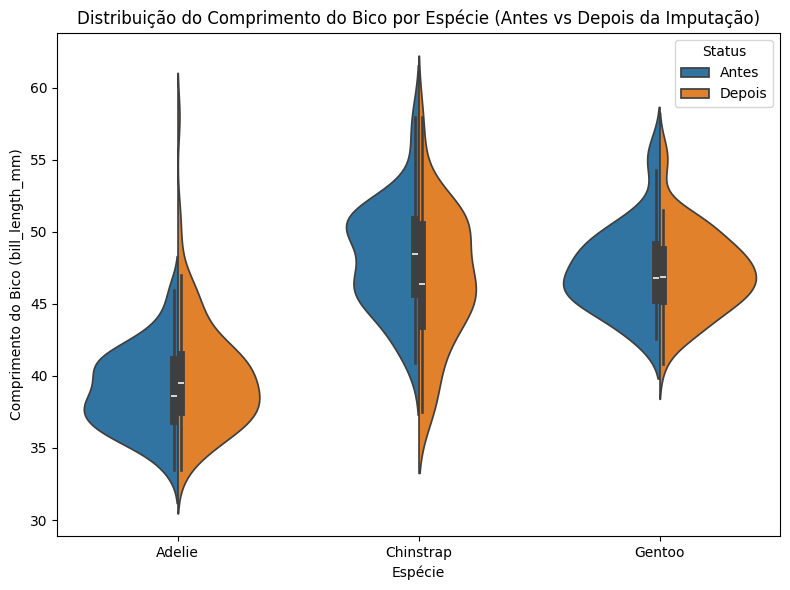

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'bill_length_mm']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'bill_length_mm']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['bill_length_mm'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='bill_length_mm', hue='status', split=True)

plt.title('Distribuição do Comprimento do Bico por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Comprimento do Bico (bill_length_mm)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

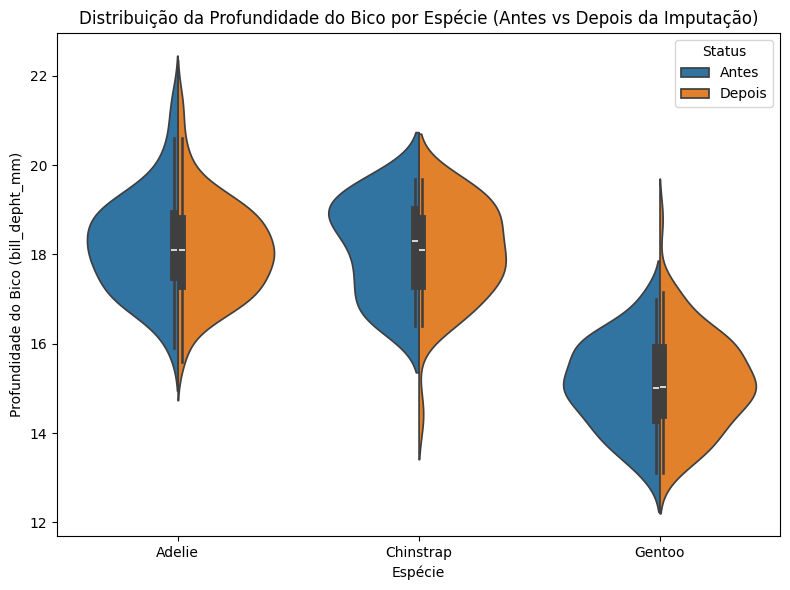

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'bill_depth_mm']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'bill_depth_mm']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['bill_depth_mm'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='bill_depth_mm', hue='status', split=True)

plt.title('Distribuição da Profundidade do Bico por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Profundidade do Bico (bill_depht_mm)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()


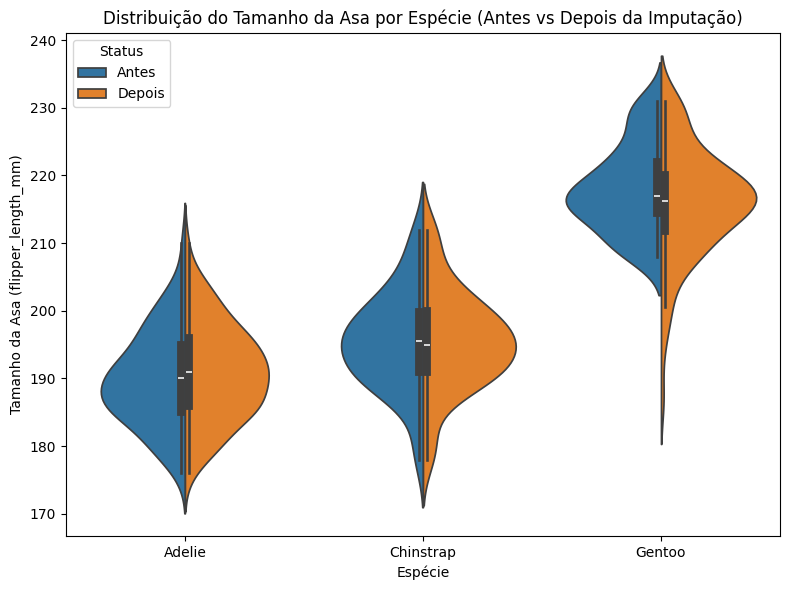

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'flipper_length_mm']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'flipper_length_mm']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['flipper_length_mm'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='flipper_length_mm', hue='status', split=True)

plt.title('Distribuição do Tamanho da Asa por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Tamanho da Asa (flipper_length_mm)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

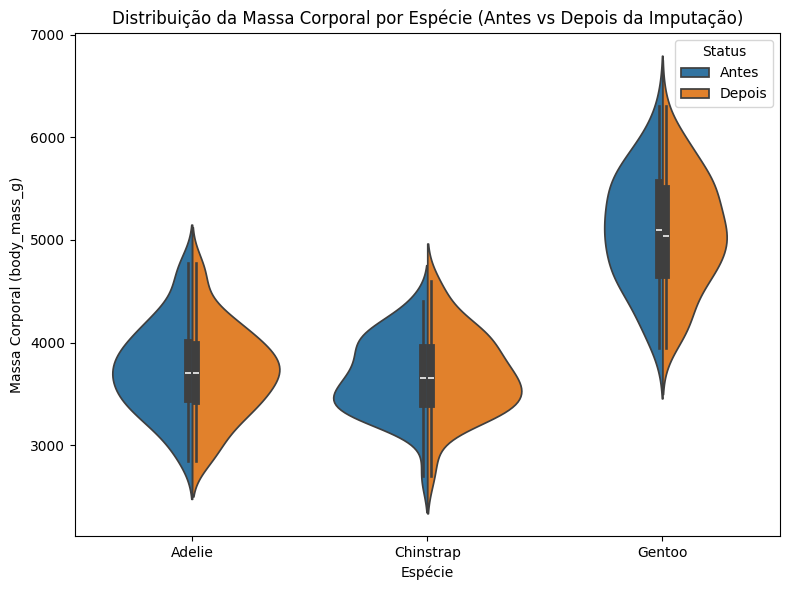

In [ ]:
#DataFrame "antes" da imputação (NaNs preservados)
df_antes = penguinsOriginalNa[['species', 'body_mass_g']].copy()
df_antes['status'] = 'Antes'

# Criar DataFrame "depois" da imputação (com valores KNN)
df_depois = penguins_numimputDF[['species', 'body_mass_g']].copy()
df_depois['status'] = 'Depois'

# Combinar os dois DataFrames e resetar o índice
df_comparativo = pd.concat([df_antes, df_depois], ignore_index=True)

# Remover valores NaN da visualização
df_comparativo = df_comparativo.dropna(subset=['body_mass_g'])

# Violin plot corrigido
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_comparativo, x='species', y='body_mass_g', hue='status', split=True)

plt.title('Distribuição da Massa Corporal por Espécie (Antes vs Depois da Imputação)')
plt.xlabel('Espécie')
plt.ylabel('Massa Corporal (body_mass_g)')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

###Junção de Colunas Categóricas e Numéricas em um CSV

In [ ]:
# Juntando os dois DataFrames lado a lado
penguins_final = pd.concat([penguins_categoricasDF, penguins_numimputDF[colunas_numericas]], axis=1)

# Salvando o resultado final
penguins_final.to_csv("PenguinsImputado.csv", index=False)

# Exibindo as primeiras linhas
penguins_final.head()

,species,island,sex,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,Male,37.650000,18.700000,180.000000,3750.000000
1,Adelie,Biscoe,Female,39.500000,17.400000,186.000000,3636.763981
2,Adelie,Torgersen,Female,40.300000,18.000000,195.000000,3250.000000
3,Adelie,Biscoe,Male,43.696137,17.158197,200.578947,4173.541667
4,Adelie,Biscoe,Male,35.000015,19.300000,193.000000,3450.000000
